In [12]:
!pip install os

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


In [13]:
!pip uninstall -y fitz PyMuPDF
!pip install pymupdf

Found existing installation: fitz 0.0.1.dev2
Uninstalling fitz-0.0.1.dev2:
  Successfully uninstalled fitz-0.0.1.dev2
Found existing installation: PyMuPDF 1.27.2.3
Uninstalling PyMuPDF-1.27.2.3:
  Successfully uninstalled PyMuPDF-1.27.2.3
  Using cached pymupdf-1.27.2.3-cp310-abi3-manylinux_2_28_x86_64.whl.metadata (24 kB)
Using cached pymupdf-1.27.2.3-cp310-abi3-manylinux_2_28_x86_64.whl (25.0 MB)


### Dlaczego wystąpił błąd?
Kod w Twojej głównej funkcji używa `fitz.open()`, co jest standardem dla biblioteki **PyMuPDF**. Jeśli jednak zainstalowałeś pakiet poleceniem `pip install fitz`, instalujesz stary, niekompatybilny moduł.

**Rozwiązanie:**
1. Uruchom powyższą komórkę z instalacją `pymupdf`.
2. Zrestartuj środowisko wykonawcze (Runtime -> Restart runtime).
3. Uruchom ponownie komórkę z definicją funkcji i skryptem.

In [1]:
import fitz  # PyMuPDF - biblioteka do przetwarzania plików PDF
import re    # Moduł do wyrażeń regularnych
import csv   # Moduł do zapisu raportu
import os    # Moduł do operacji na systemie plików (foldery, pliki)
import time  # Moduł do pomiaru czasu przetwarzania

def process_pdfs_in_directory(input_dir, output_dir, output_csv):
    """
    Funkcja analizująca wszystkie pliki PDF we wskazanym folderze wejściowym.
    Wyodrębnia obrazy tabel (szukając wycentrowanego nagłówka 'Table X.Y')
    ORAZ wykresy/figury (szukając nagłówka 'Figure X.Y' lub 'Fig. X.Y').
    Zapisuje je jako pliki PNG, a informacje o nich zrzuca do pliku CSV.
    """

    # 1. Sprawdzenie i utworzenie folderu docelowego, jeśli nie istnieje
    start_time = time.time()

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Utworzono folder docelowy: {output_dir}")
    else:
        print(f"Folder docelowy istnieje: {output_dir}")

    # 2. Inicjalizacja wyrażeń regularnych dla TABEL
    table_pattern = re.compile(r'(?i)^\s*Table\s+([\d\.]+)')

    # 3. Inicjalizacja wyrażeń regularnych dla FIGUR/WYKRESÓW
    figure_pattern = re.compile(r'(?i)^\s*(?:Figure|Fig\.?)\s*([\d\.]+)')

    # Wyrażenie do szukania cyfr - posłuży do znalezienia numeru strony
    digit_pattern = re.compile(r'\d+')

    # Wyrażenie do wykrywania podpisów pod figurami (często zawierają "Figure")
    caption_pattern = re.compile(r'(?i)Figure\s+[\d\.]+')

    # 4. Pobranie listy plików PDF z folderu wejściowego
    pdf_files = [f for f in os.listdir(input_dir) if f.lower().endswith('.pdf')]

    if not pdf_files:
        print(f"Brak plików PDF do przetworzenia w folderze: {input_dir}")
        return

    print(f"Znaleziono {len(pdf_files)} plików PDF do przetworzenia.")

    # 5. Liczniki statystyk
    total_tables = 0
    total_figures = 0
    total_errors = 0

    # 6. Otwarcie pliku CSV do zapisu wyników
    with open(output_csv, mode='w', newline='', encoding='utf-8-sig') as csv_file:
        writer = csv.writer(csv_file, delimiter=';')
        writer.writerow(['Plik źródłowy', 'Numer strony', 'Typ', 'Nazwa', 'Plik PNG'])

        # 7. Główna pętla przechodząca przez wszystkie pliki PDF
        for pdf_index, pdf_filename in enumerate(pdf_files, 1):
            pdf_path = os.path.join(input_dir, pdf_filename)
            print(f"\n[{pdf_index}/{len(pdf_files)}] Rozpoczynam przetwarzanie pliku: {pdf_filename}...")

            try:
                doc = fitz.open(pdf_path)
            except Exception as e:
                print(f"BŁĄD podczas otwierania pliku {pdf_filename}: {e}")
                total_errors += 1
                continue

            pdf_basename = os.path.splitext(pdf_filename)[0]
            file_tables = 0
            file_figures = 0

            # 8. Pętla przechodząca przez strony
            for page_num in range(len(doc)):
                page = doc[page_num]
                page_dict = page.get_text("dict")
                blocks = page_dict.get("blocks", [])
                lines_data = []

                for b in blocks:
                    if b.get("type") == 0:
                        for l in b.get("lines", []):
                            text = "".join([s["text"] for s in l.get("spans", [])]).strip()
                            if text:
                                lines_data.append({"text": text, "bbox": l["bbox"]})

                if not lines_data: continue
                lines_data.sort(key=lambda x: x["bbox"][1])
                page_width = page.rect.width
                page_height = page.rect.height

                # --- SZUKANIE TABEL I FIGUR ---
                i = 0
                while i < len(lines_data):
                    line = lines_data[i]
                    text = line["text"]
                    table_match = table_pattern.search(text)
                    figure_match = figure_pattern.search(text)
                    detected_type = "Table" if table_match else "Figure" if figure_match else None
                    match_obj = table_match if table_match else figure_match

                    if match_obj:
                        x0, y0, x1, y1 = line["bbox"]
                        item_name = match_obj.group(0).strip()
                        left_margin, right_margin = x0, page_width - x1

                        if abs(left_margin - right_margin) < (0.25 * page_width):
                            start_y = y0
                            header_line_height = y1 - y0
                            j = i + 1
                            current_max_y1 = y1

                            while j < len(lines_data):
                                next_line = lines_data[j]
                                if (next_line["bbox"][1] - current_max_y1) > 4.0 * header_line_height: break
                                current_max_y1 = max(current_max_y1, next_line["bbox"][3])
                                j += 1

                            crop_rect = fitz.Rect(0, max(0, start_y - 10), page_width, min(current_max_y1 + 10, page_height))
                            safe_item_name = item_name.replace(' ', '_').replace('.', '_')
                            png_filename = f"{pdf_basename}_str_{page_num+1}_{detected_type}_{safe_item_name}.png"
                            png_filepath = os.path.join(output_dir, png_filename)

                            try:
                                pix = page.get_pixmap(clip=crop_rect, dpi=300)
                                pix.save(png_filepath)
                                writer.writerow([pdf_filename, page_num+1, detected_type, item_name, png_filename])
                                if detected_type == "Table": total_tables += 1
                                else: total_figures += 1
                                i = j - 1
                            except Exception: pass
                    i += 1
            doc.close()
    print(f"Zakończono! Znaleziono {total_tables} tabel i {total_figures} figur.")

if __name__ == "__main__":
    INPUT_DIR = "/content/"
    # NAPRAWIONO LITERÓWKĘ: /conetnt/ -> /content/output_images/
    OUTPUT_DIR = "/content/output_images/"
    CSV_PATH = "/content/info.csv"
    process_pdfs_in_directory(INPUT_DIR, OUTPUT_DIR, CSV_PATH)

Folder docelowy istnieje: /content/output_images/
Znaleziono 4 plików PDF do przetworzenia.

[1/4] Rozpoczynam przetwarzanie pliku: bulkowski_page_044.pdf...

[2/4] Rozpoczynam przetwarzanie pliku: bulkowski_page_046.pdf...

[3/4] Rozpoczynam przetwarzanie pliku: bulkowski_page_047.pdf...

[4/4] Rozpoczynam przetwarzanie pliku: bulkowski_page_039.pdf...
Zakończono! Znaleziono 5 tabel i 1 figur.


Znaleziono 5 obraz3w:

Plik: bulkowski_page_039_str_1_Figure_Figure_1_3.png


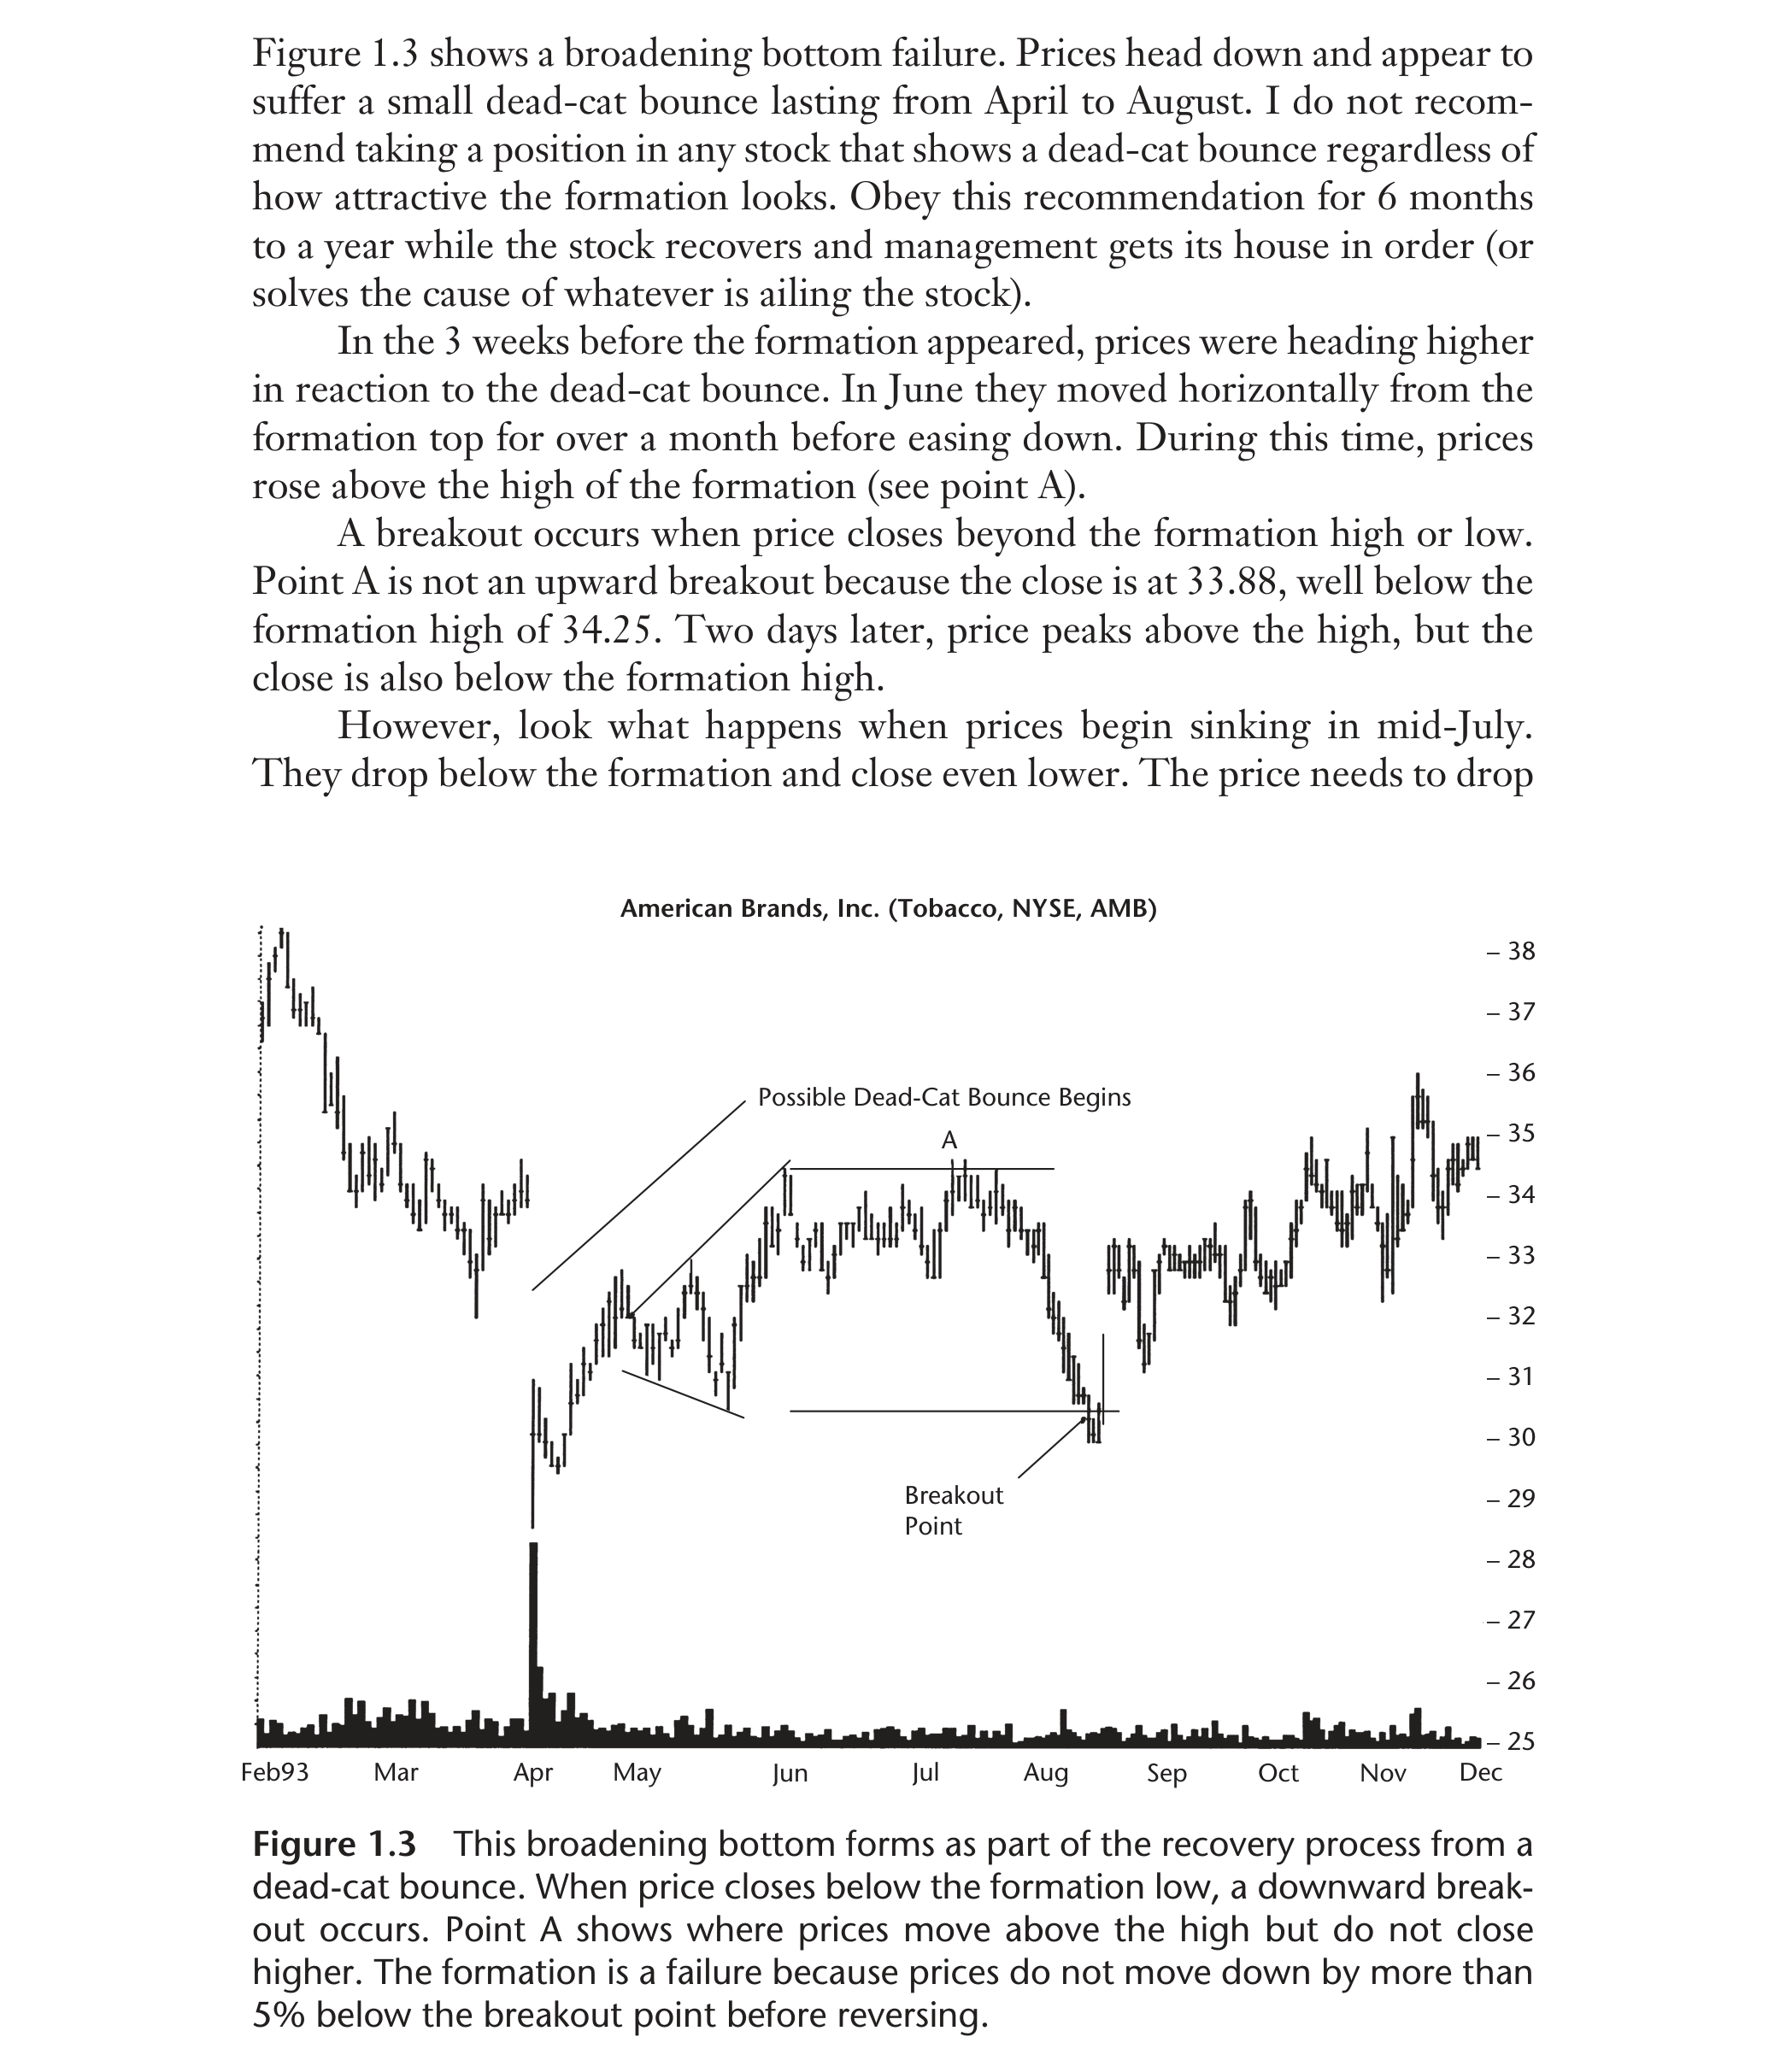


Plik: bulkowski_page_044_str_1_Table_Table_1_5.png


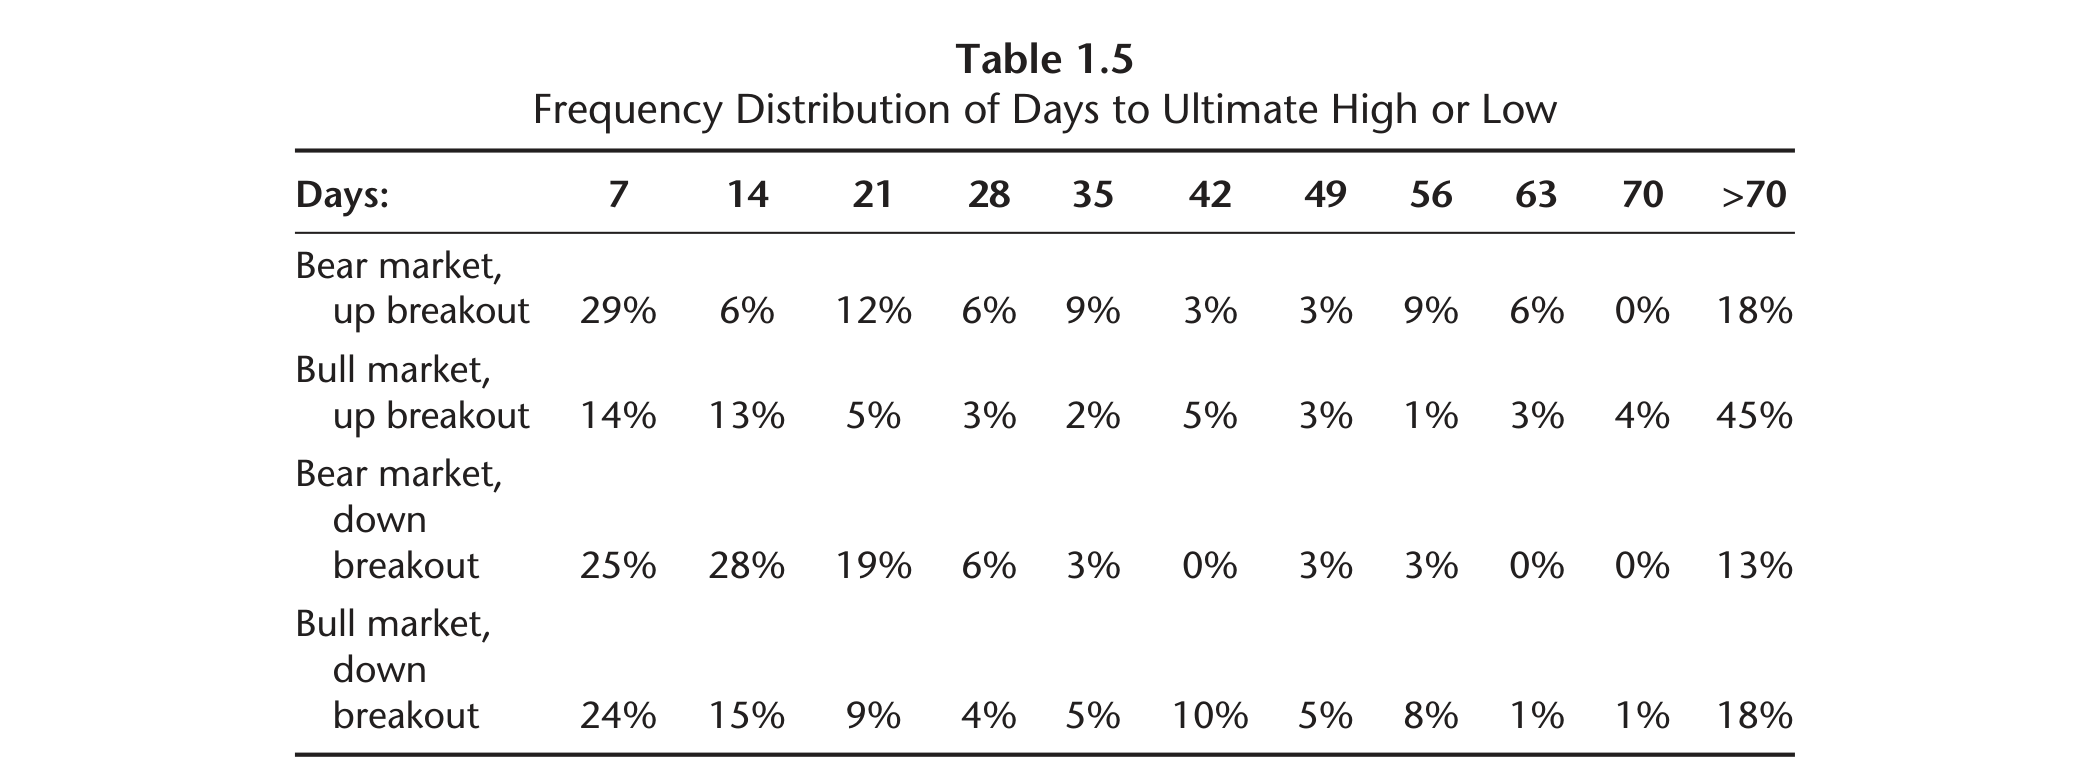


Plik: bulkowski_page_046_str_1_Table_Table_1_7.png


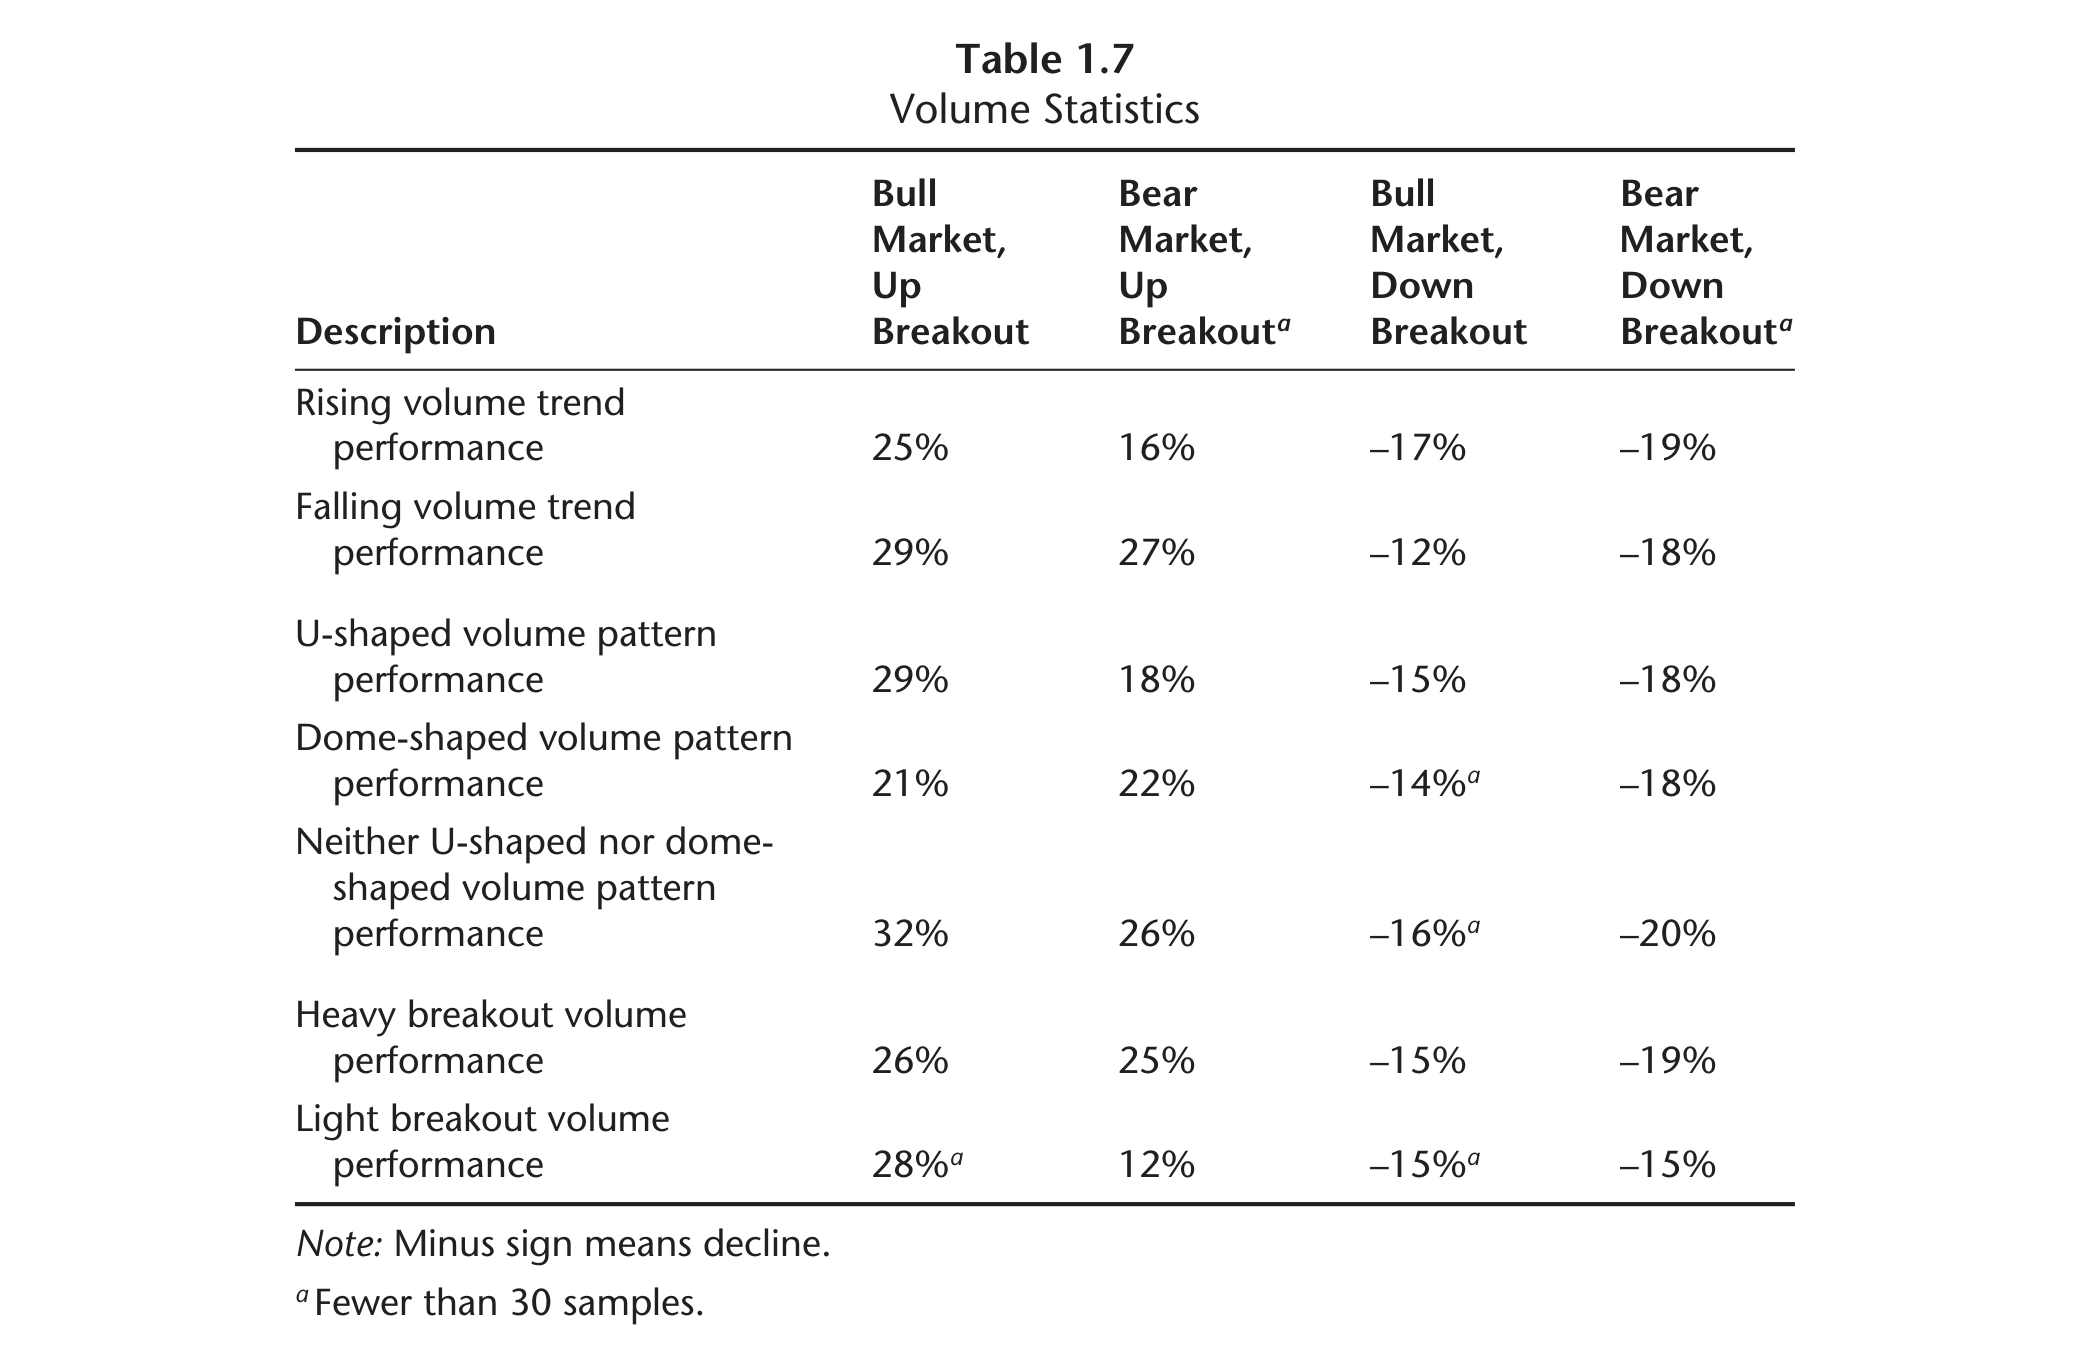


Plik: bulkowski_page_046_str_1_Table_Table_1_8.png


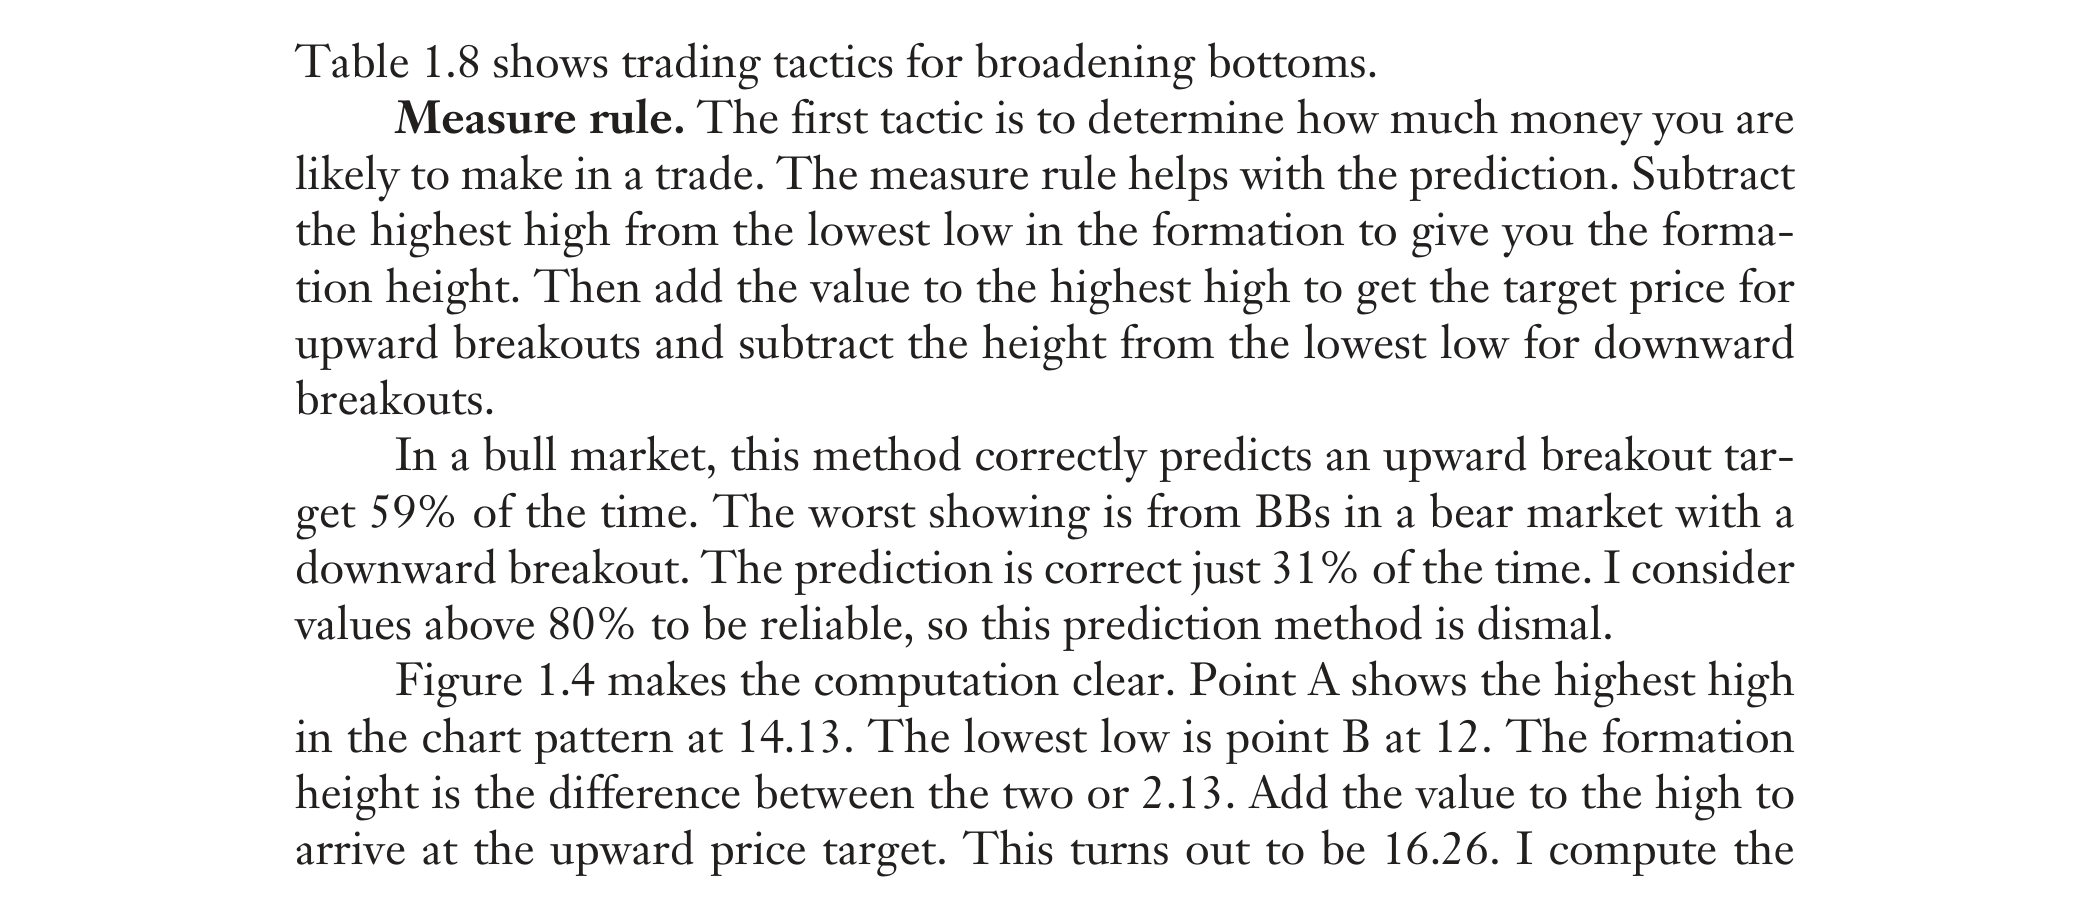


Plik: bulkowski_page_047_str_1_Table_Table_1_8.png


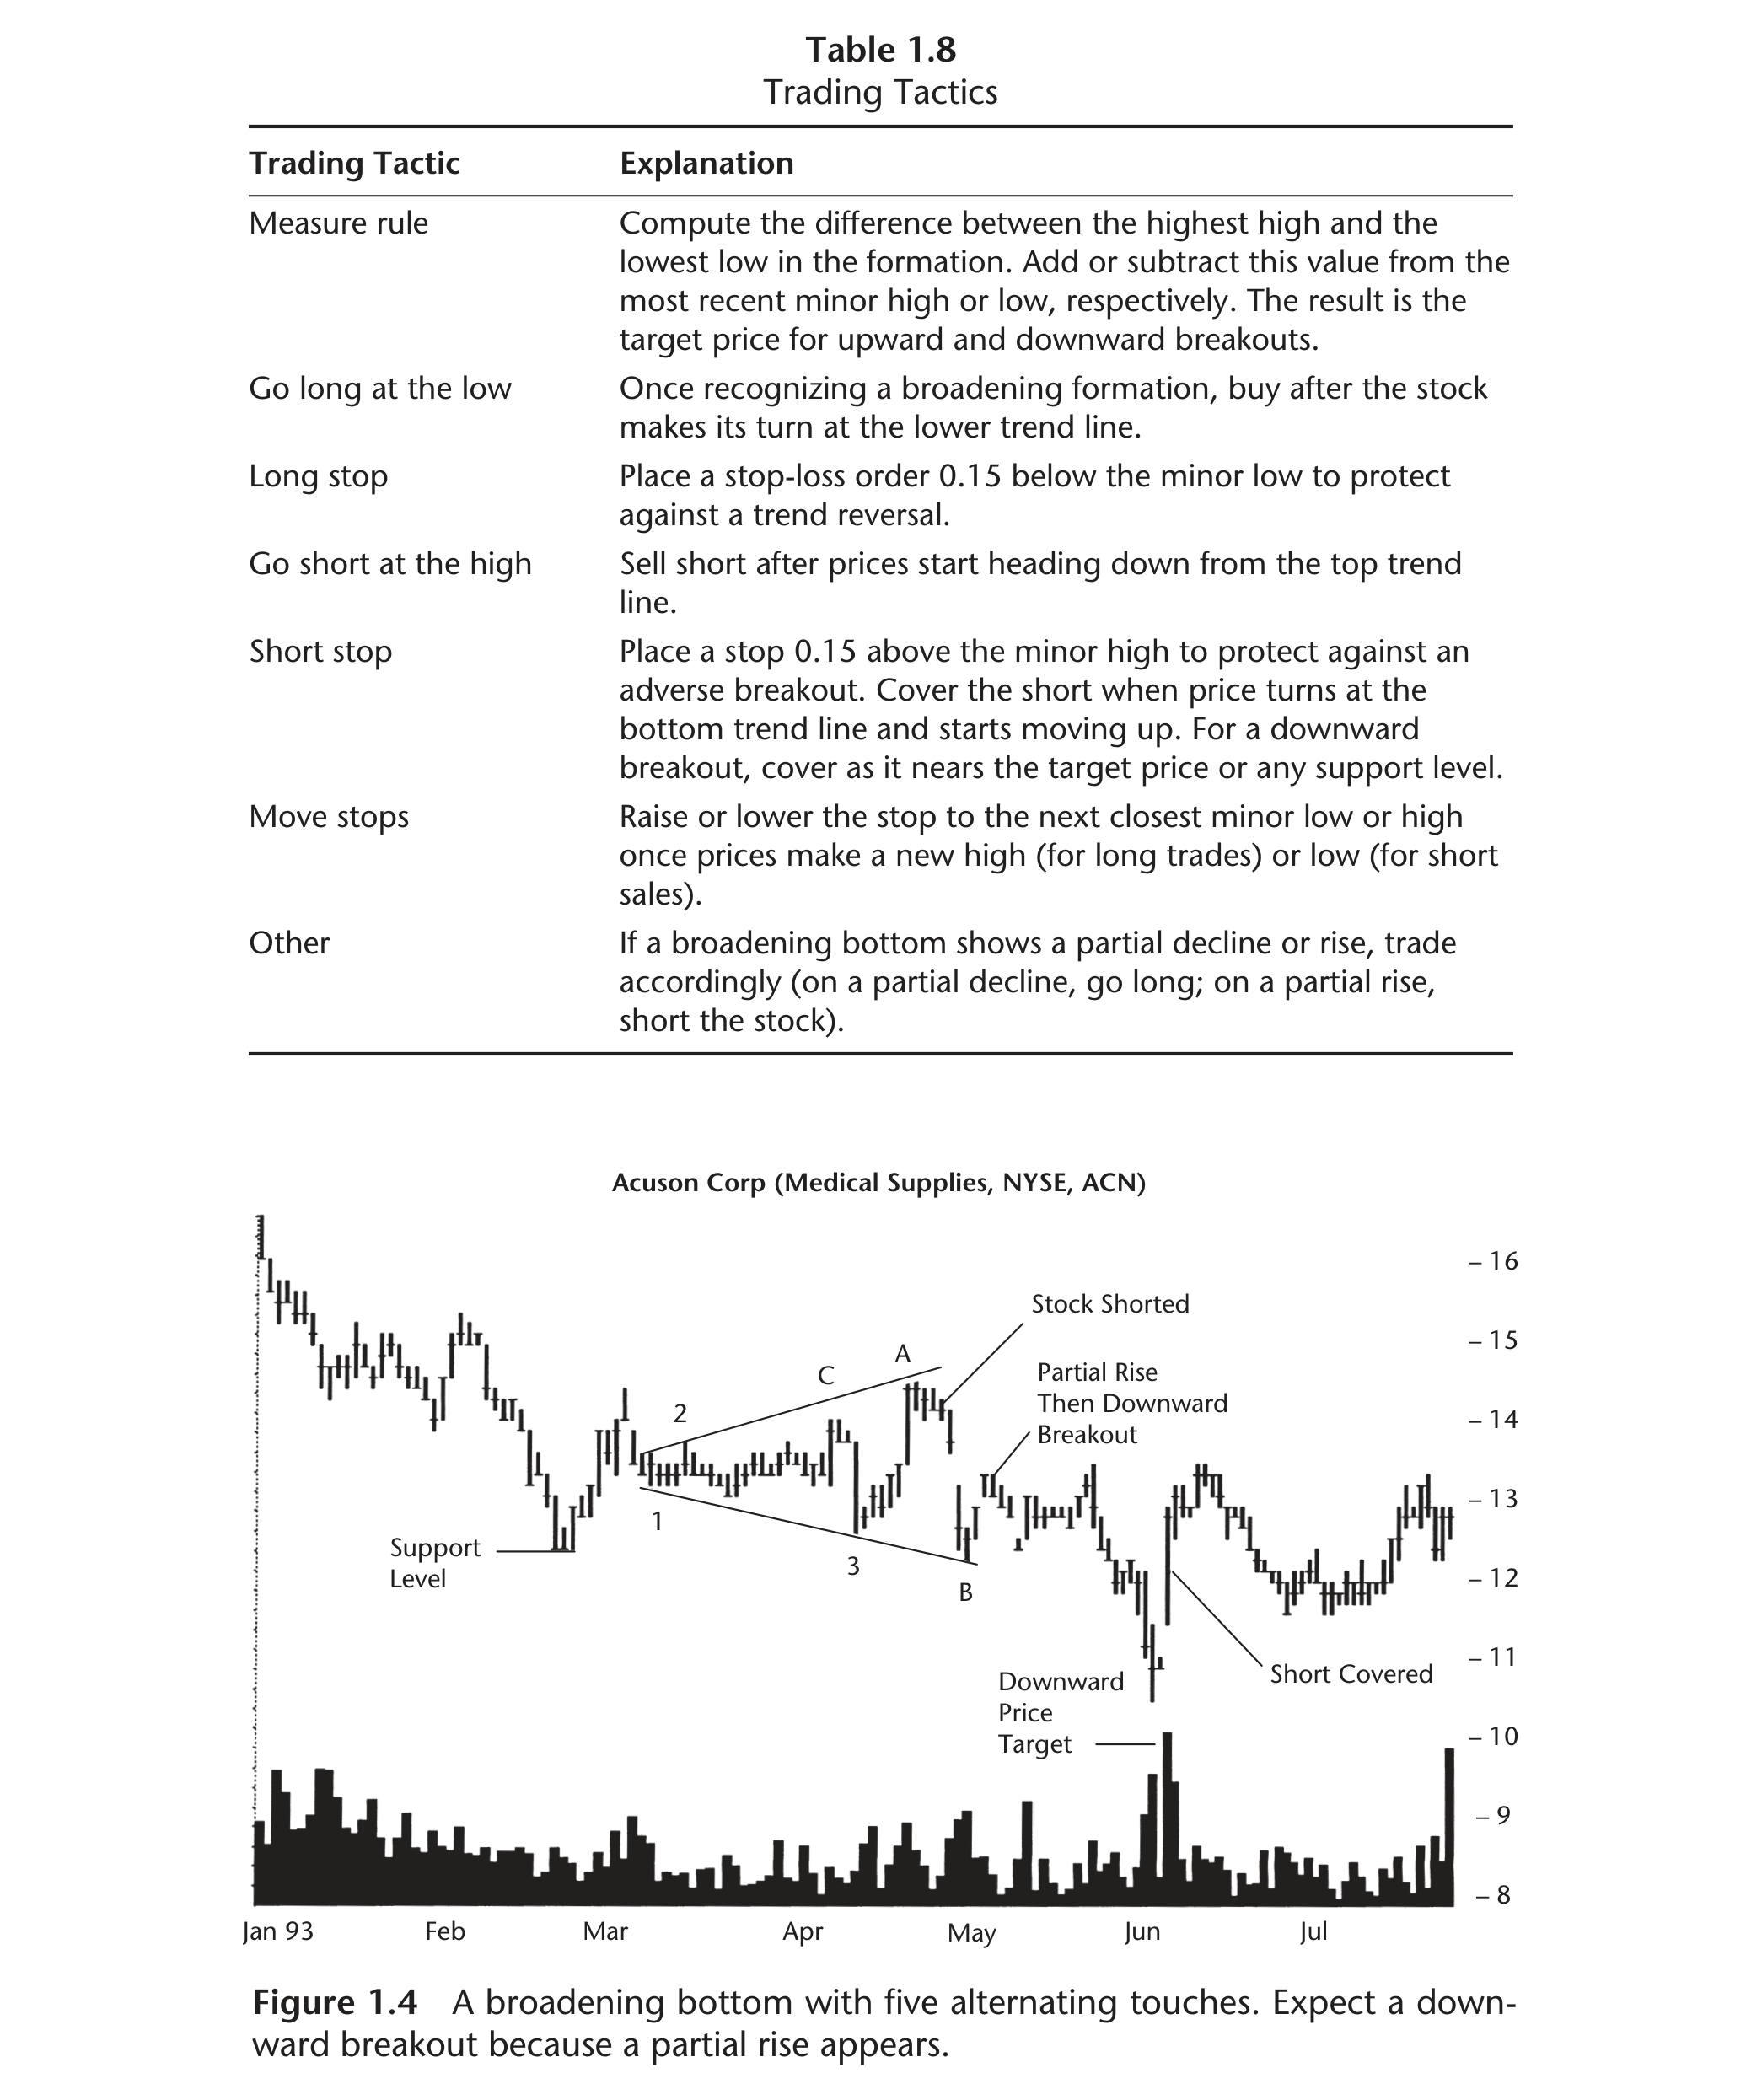

In [2]:
import os
from IPython.display import Image, display

output_dir = '/content/output_images/'
if os.path.exists(output_dir):
    image_files = [f for f in os.listdir(output_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if image_files:
        print(f"Znaleziono {len(image_files)} obraz3w:")
        for img_file in sorted(image_files):
            print(f"\nPlik: {img_file}")
            display(Image(filename=os.path.join(output_dir, img_file), width=600))
    else:
        print("Folder istnieje, ale nie znaleziono w nim plik3w graficznych.")
else:
    print(f"Folder {output_dir} nie istnieje. Upewnij się, Űe skrypt ekstrakcji zakończył się pomyřlnie.")

In [7]:
!pip install tools